# CDT Paper - Figure 5: FNDC5 Case Study (Updated)

**Version**: v3.3.1 (dropout 0.3)
**Date**: 2025-12-23

Updates:
- Temperature scaling (T=0.3) for attention visualization
- Arrow annotations instead of vertical lines
- Corrected Panel C with FNDC5 direction

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path
import torch
import torch.nn as nn
from dataclasses import dataclass
from typing import Optional
import h5py
from tqdm import tqdm
from torch.utils.data import Dataset
import shutil

DRIVE_OUTPUT = Path("/content/drive/MyDrive/cdt_outputs/v3_3_1_dropout03")
DRIVE_DATA = Path("/content/drive/MyDrive/cdt_data")

COLAB_DATA = Path("/content/colab_data_v3")
COLAB_DATA.mkdir(exist_ok=True)
TRAINING_DIR = COLAB_DATA / "training"
TRAINING_DIR.mkdir(exist_ok=True)

print("Setup complete")

Setup complete


In [ ]:
# Copy data
files_to_copy = [
    "human_proteomelm_embeddings_aligned.h5",
    "k562_gene_embeddings_aligned.h5",
    "protein_index_mapping_aligned.npz",
]
for f in files_to_copy:
    src = DRIVE_DATA / f
    dst = COLAB_DATA / f
    if src.exists() and not dst.exists():
        print(f"Copying {f}...")
        shutil.copy(src, dst)

val_src = DRIVE_DATA / "training" / "gasperini_val.h5"
val_dst = TRAINING_DIR / "gasperini_val.h5"
if val_src.exists() and not val_dst.exists():
    print("Copying gasperini_val.h5...")
    shutil.copy(val_src, val_dst)
print("Done!")

Copying human_proteomelm_embeddings_aligned.h5...
Copying k562_gene_embeddings_aligned.h5...
Copying protein_index_mapping_aligned.npz...
Copying gasperini_val.h5...
Done!


In [ ]:
# Model Definition
@dataclass
class CDTv33Config:
    dna_dim: int = 3072
    dna_seq_len: int = 896
    protein_dim: int = 768
    rna_dim: int = 512
    n_proteins: int = 2360
    hidden_dim: int = 768
    nhead: int = 8
    dropout: float = 0.3
    dna_self_attn_layers: int = 2
    rna_self_attn_layers: int = 1
    protein_self_attn_layers: int = 1

class SequenceProjector(nn.Module):
    def __init__(self, input_dim, output_dim, dropout=0.1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.dropout(self.norm(self.linear(x)))

class SelfAttentionBlock(nn.Module):
    def __init__(self, d_model, nhead=4, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_model*4), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model*4, d_model), nn.Dropout(dropout))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, return_attention=False):
        attn_out, attn_weights = self.self_attn(x, x, x, need_weights=return_attention, average_attn_weights=False)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))
        return x, attn_weights if return_attention else None

class CrossAttentionBlock(nn.Module):
    def __init__(self, d_model, nhead=4, dropout=0.1):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_model*4), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model*4, d_model), nn.Dropout(dropout))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, query, key_value):
        attn_out, attn_weights = self.cross_attn(query, key_value, key_value, need_weights=True, average_attn_weights=False)
        x = self.norm1(query + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))
        return x, attn_weights

class VirtualCellEmbedderWithAttention(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.dna_query = nn.Parameter(torch.randn(1,1,d_model))
        self.rna_query = nn.Parameter(torch.randn(1,1,d_model))
        self.protein_query = nn.Parameter(torch.randn(1,1,d_model))
        self.dna_attn = nn.MultiheadAttention(d_model, 4, dropout=dropout, batch_first=True)
        self.rna_attn = nn.MultiheadAttention(d_model, 4, dropout=dropout, batch_first=True)
        self.protein_attn = nn.MultiheadAttention(d_model, 4, dropout=dropout, batch_first=True)
        self.fusion = nn.Sequential(nn.Linear(d_model*3, d_model*2), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model*2, d_model), nn.LayerNorm(d_model))
    def forward(self, dna, rna, protein):
        bs = dna.size(0)
        dna_p, _ = self.dna_attn(self.dna_query.expand(bs,-1,-1), dna, dna)
        rna_p, _ = self.rna_attn(self.rna_query.expand(bs,-1,-1), rna, rna)
        prot_p, _ = self.protein_attn(self.protein_query.expand(bs,-1,-1), protein, protein)
        return self.fusion(torch.cat([dna_p.squeeze(1), rna_p.squeeze(1), prot_p.squeeze(1)], dim=-1))

class CDTv33Model(nn.Module):
    def __init__(self, config=None):
        super().__init__()
        if config is None: config = CDTv33Config()
        self.config = config
        self.dna_projector = SequenceProjector(config.dna_dim, config.hidden_dim, config.dropout)
        self.rna_projector = SequenceProjector(config.rna_dim, config.hidden_dim, config.dropout)
        self.protein_projector = SequenceProjector(config.protein_dim, config.hidden_dim, config.dropout)
        self.dna_self_attn_layers = nn.ModuleList([SelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout) for _ in range(config.dna_self_attn_layers)])
        self.rna_self_attn_layers = nn.ModuleList([SelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout) for _ in range(config.rna_self_attn_layers)])
        self.protein_self_attn_layers = nn.ModuleList([SelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout) for _ in range(config.protein_self_attn_layers)])
        self.dna_to_rna = CrossAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
        self.rna_to_protein = CrossAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
        self.vce = VirtualCellEmbedderWithAttention(config.hidden_dim, config.dropout)
        self.task_layer = nn.Sequential(nn.Linear(config.hidden_dim, config.hidden_dim), nn.GELU(), nn.Dropout(config.dropout), nn.Linear(config.hidden_dim, config.n_proteins))

    def forward(self, dna_emb, protein_emb, rna_emb, return_attention=False):
        bs = dna_emb.size(0)
        attention_maps = {}
        dna = self.dna_projector(dna_emb)
        rna = self.rna_projector(rna_emb)
        protein = self.protein_projector(protein_emb).unsqueeze(0).expand(bs,-1,-1)
        for layer in self.dna_self_attn_layers: dna, _ = layer(dna)
        for layer in self.rna_self_attn_layers: rna, _ = layer(rna)
        for layer in self.protein_self_attn_layers: protein, _ = layer(protein)
        rna_fused, dna_to_rna_attn = self.dna_to_rna(query=rna, key_value=dna)
        if return_attention: attention_maps['dna_to_rna'] = dna_to_rna_attn
        protein_fused, rna_to_prot_attn = self.rna_to_protein(query=protein, key_value=rna_fused)
        if return_attention: attention_maps['rna_to_protein'] = rna_to_prot_attn
        cell_emb = self.vce(dna, rna_fused, protein_fused)
        logits = self.task_layer(cell_emb)
        if return_attention: return logits, attention_maps
        return logits

print("Model defined.")

Model defined.


In [ ]:
# Dataset
class ValidationDataset(Dataset):
    def __init__(self, val_path, dna_path, protein_path, rna_path, mapping_path):
        data = np.load(mapping_path, allow_pickle=True)
        self.old_to_new_idx = {int(p[0]): int(p[1]) for p in data['old_to_new']}
        with h5py.File(val_path, 'r') as f:
            orig_protein_idx = f['esm2_idx'][:]
            self.beta_values = f['beta'][:] if 'beta' in f else np.zeros_like(f['labels'][:], dtype=np.float32)
            self.enhancer_chr = [c.decode() if isinstance(c, bytes) else c for c in f['enhancer_chr'][:]]
            self.enhancer_start = f['enhancer_start'][:]
            self.enhancer_end = f['enhancer_end'][:]
        valid_mask = np.array([int(idx) in self.old_to_new_idx for idx in orig_protein_idx])
        self.beta_values = self.beta_values[valid_mask]
        self.enhancer_chr = [c for c, v in zip(self.enhancer_chr, valid_mask) if v]
        self.enhancer_start = self.enhancer_start[valid_mask]
        self.enhancer_end = self.enhancer_end[valid_mask]
        self.protein_idx = np.array([self.old_to_new_idx[int(idx)] for idx in orig_protein_idx[valid_mask]])
        self.enhancer_centers = (self.enhancer_start + self.enhancer_end) // 2

        self.dna_file = h5py.File(dna_path, 'r')
        self.dna_emb = self.dna_file['embeddings']
        self.dna_centers = self.dna_file['centers'][:]
        self.dna_chroms = [c.decode() if isinstance(c, bytes) else c for c in self.dna_file['chroms'][:]]
        with h5py.File(protein_path, 'r') as f:
            self.protein_emb = f['embeddings'][:]
            self.protein_genes = [g.decode() if isinstance(g, bytes) else g for g in f['gene_names'][:]]
        with h5py.File(rna_path, 'r') as f:
            self.rna_emb = f['embeddings'][:]
        self._create_dna_mapping()
        print(f"Validation samples: {len(self.beta_values)}")

    def _create_dna_mapping(self):
        dna_coord_to_idx = {(c, int(ctr)): i for i, (c, ctr) in enumerate(zip(self.dna_chroms, self.dna_centers))}
        self.sample_to_dna_idx = {}
        self.sample_to_dna_center = {}
        for idx in range(len(self.enhancer_chr)):
            chrom, center = self.enhancer_chr[idx], self.enhancer_centers[idx]
            if (chrom, center) in dna_coord_to_idx:
                self.sample_to_dna_idx[idx] = dna_coord_to_idx[(chrom, center)]
                self.sample_to_dna_center[idx] = center
            else:
                for (c, ctr), dna_idx in dna_coord_to_idx.items():
                    if c == chrom and abs(ctr - center) <= 1000:
                        self.sample_to_dna_idx[idx] = dna_idx
                        self.sample_to_dna_center[idx] = ctr
                        break
                else:
                    self.sample_to_dna_idx[idx] = None
                    self.sample_to_dna_center[idx] = None

    def __len__(self): return len(self.beta_values)

    def __getitem__(self, idx):
        dna_idx = self.sample_to_dna_idx.get(idx)
        dna_emb = self.dna_emb[dna_idx,:,:].astype(np.float32) if dna_idx else np.zeros((896,3072), dtype=np.float32)
        return {
            'dna_emb': torch.from_numpy(dna_emb),
            'rna_emb': torch.from_numpy(self.rna_emb.astype(np.float32)),
            'protein_idx': torch.tensor(int(self.protein_idx[idx]), dtype=torch.long),
            'beta': torch.tensor(self.beta_values[idx], dtype=torch.float32),
            'enhancer_center': self.enhancer_centers[idx],
        }

    def get_protein_embeddings(self): return torch.from_numpy(self.protein_emb.astype(np.float32))
    def close(self): self.dna_file.close()

print("Dataset defined.")

Dataset defined.


In [ ]:
# Load dataset
val_dataset = ValidationDataset(
    val_path=TRAINING_DIR / "gasperini_val.h5",
    dna_path=DRIVE_DATA / "pilot_full_v2.h5",
    protein_path=COLAB_DATA / "human_proteomelm_embeddings_aligned.h5",
    rna_path=COLAB_DATA / "k562_gene_embeddings_aligned.h5",
    mapping_path=COLAB_DATA / "protein_index_mapping_aligned.npz"
)

Validation samples: 996


In [ ]:
# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = CDTv33Model(CDTv33Config()).to(device)
model.load_state_dict(torch.load(DRIVE_OUTPUT / "cdt_v3_3_1_dropout03_best.pt", map_location=device))
model.eval()

protein_emb = val_dataset.get_protein_embeddings().to(device)
print(f"Model loaded.")

Device: cuda
Model loaded.


In [ ]:
# Find FNDC5 sample (strongest effect)
strongest_idx = np.argmin(val_dataset.beta_values)
strongest_beta = val_dataset.beta_values[strongest_idx]
strongest_protein_idx = val_dataset.protein_idx[strongest_idx]
target_gene = val_dataset.protein_genes[strongest_protein_idx]

print(f"Strongest effect sample:")
print(f"  Sample index: {strongest_idx}")
print(f"  Beta: {strongest_beta:.4f}")
print(f"  Target gene: {target_gene}")
print(f"  Chromosome: {val_dataset.enhancer_chr[strongest_idx]}")
print(f"  Enhancer center: {val_dataset.enhancer_centers[strongest_idx]:,}")

fndc5_idx = strongest_idx

Strongest effect sample:
  Sample index: 538
  Beta: -1.3102
  Target gene: FNDC5
  Chromosome: chr1
  Enhancer center: 33,592,976


In [ ]:
# Extract Attention and Gradient
BIN_SIZE = 128  # bp per bin
SEQ_LEN = 896   # number of bins
CENTER_BIN = 448  # center bin index

def bin_to_kb(bin_idx):
    return (bin_idx - CENTER_BIN) * BIN_SIZE / 1000

sample = val_dataset[fndc5_idx]
dna = sample['dna_emb'].unsqueeze(0).to(device).requires_grad_(True)
rna = sample['rna_emb'].unsqueeze(0).to(device)
protein_idx = sample['protein_idx'].item()
enhancer_center = sample['enhancer_center']

# Forward with attention
logits, attention_maps = model(dna, protein_emb, rna, return_attention=True)
pred = logits[0, protein_idx]

# Backward for gradient
pred.backward()

# Get gradient importance (L2 norm)
dna_grad = dna.grad[0].detach().cpu().numpy()
gradient_importance = np.linalg.norm(dna_grad, axis=1)

# Get attention for target gene
dna_to_rna_attn = attention_maps['dna_to_rna'][0].detach().cpu().numpy()
attention_avg = dna_to_rna_attn.mean(axis=0)
gene_attention = attention_avg[protein_idx]

# Find peaks
attention_peak_bin = np.argmax(gene_attention)
gradient_peak_bin = np.argmax(gradient_importance)

attention_peak_kb = bin_to_kb(attention_peak_bin)
gradient_peak_kb = bin_to_kb(gradient_peak_bin)

print(f"\nAnalysis results:")
print(f"  Attention peak: bin {attention_peak_bin} ({attention_peak_kb:+.1f} kb from center)")
print(f"  Gradient peak: bin {gradient_peak_bin} ({gradient_peak_kb:+.1f} kb from center)")
print(f"  Prediction: {pred.item():.4f}")
print(f"  Actual beta: {sample['beta'].item():.4f}")


Analysis results:
  Attention peak: bin 818 (+47.4 kb from center)
  Gradient peak: bin 5 (-56.7 kb from center)
  Prediction: -0.5635
  Actual beta: -1.3102


After temperature scaling (T=0.3):
  Attention peak: bin 818 (+47.4 kb)
  Max attention value: 0.001302
  Sum of attention: 1.000000


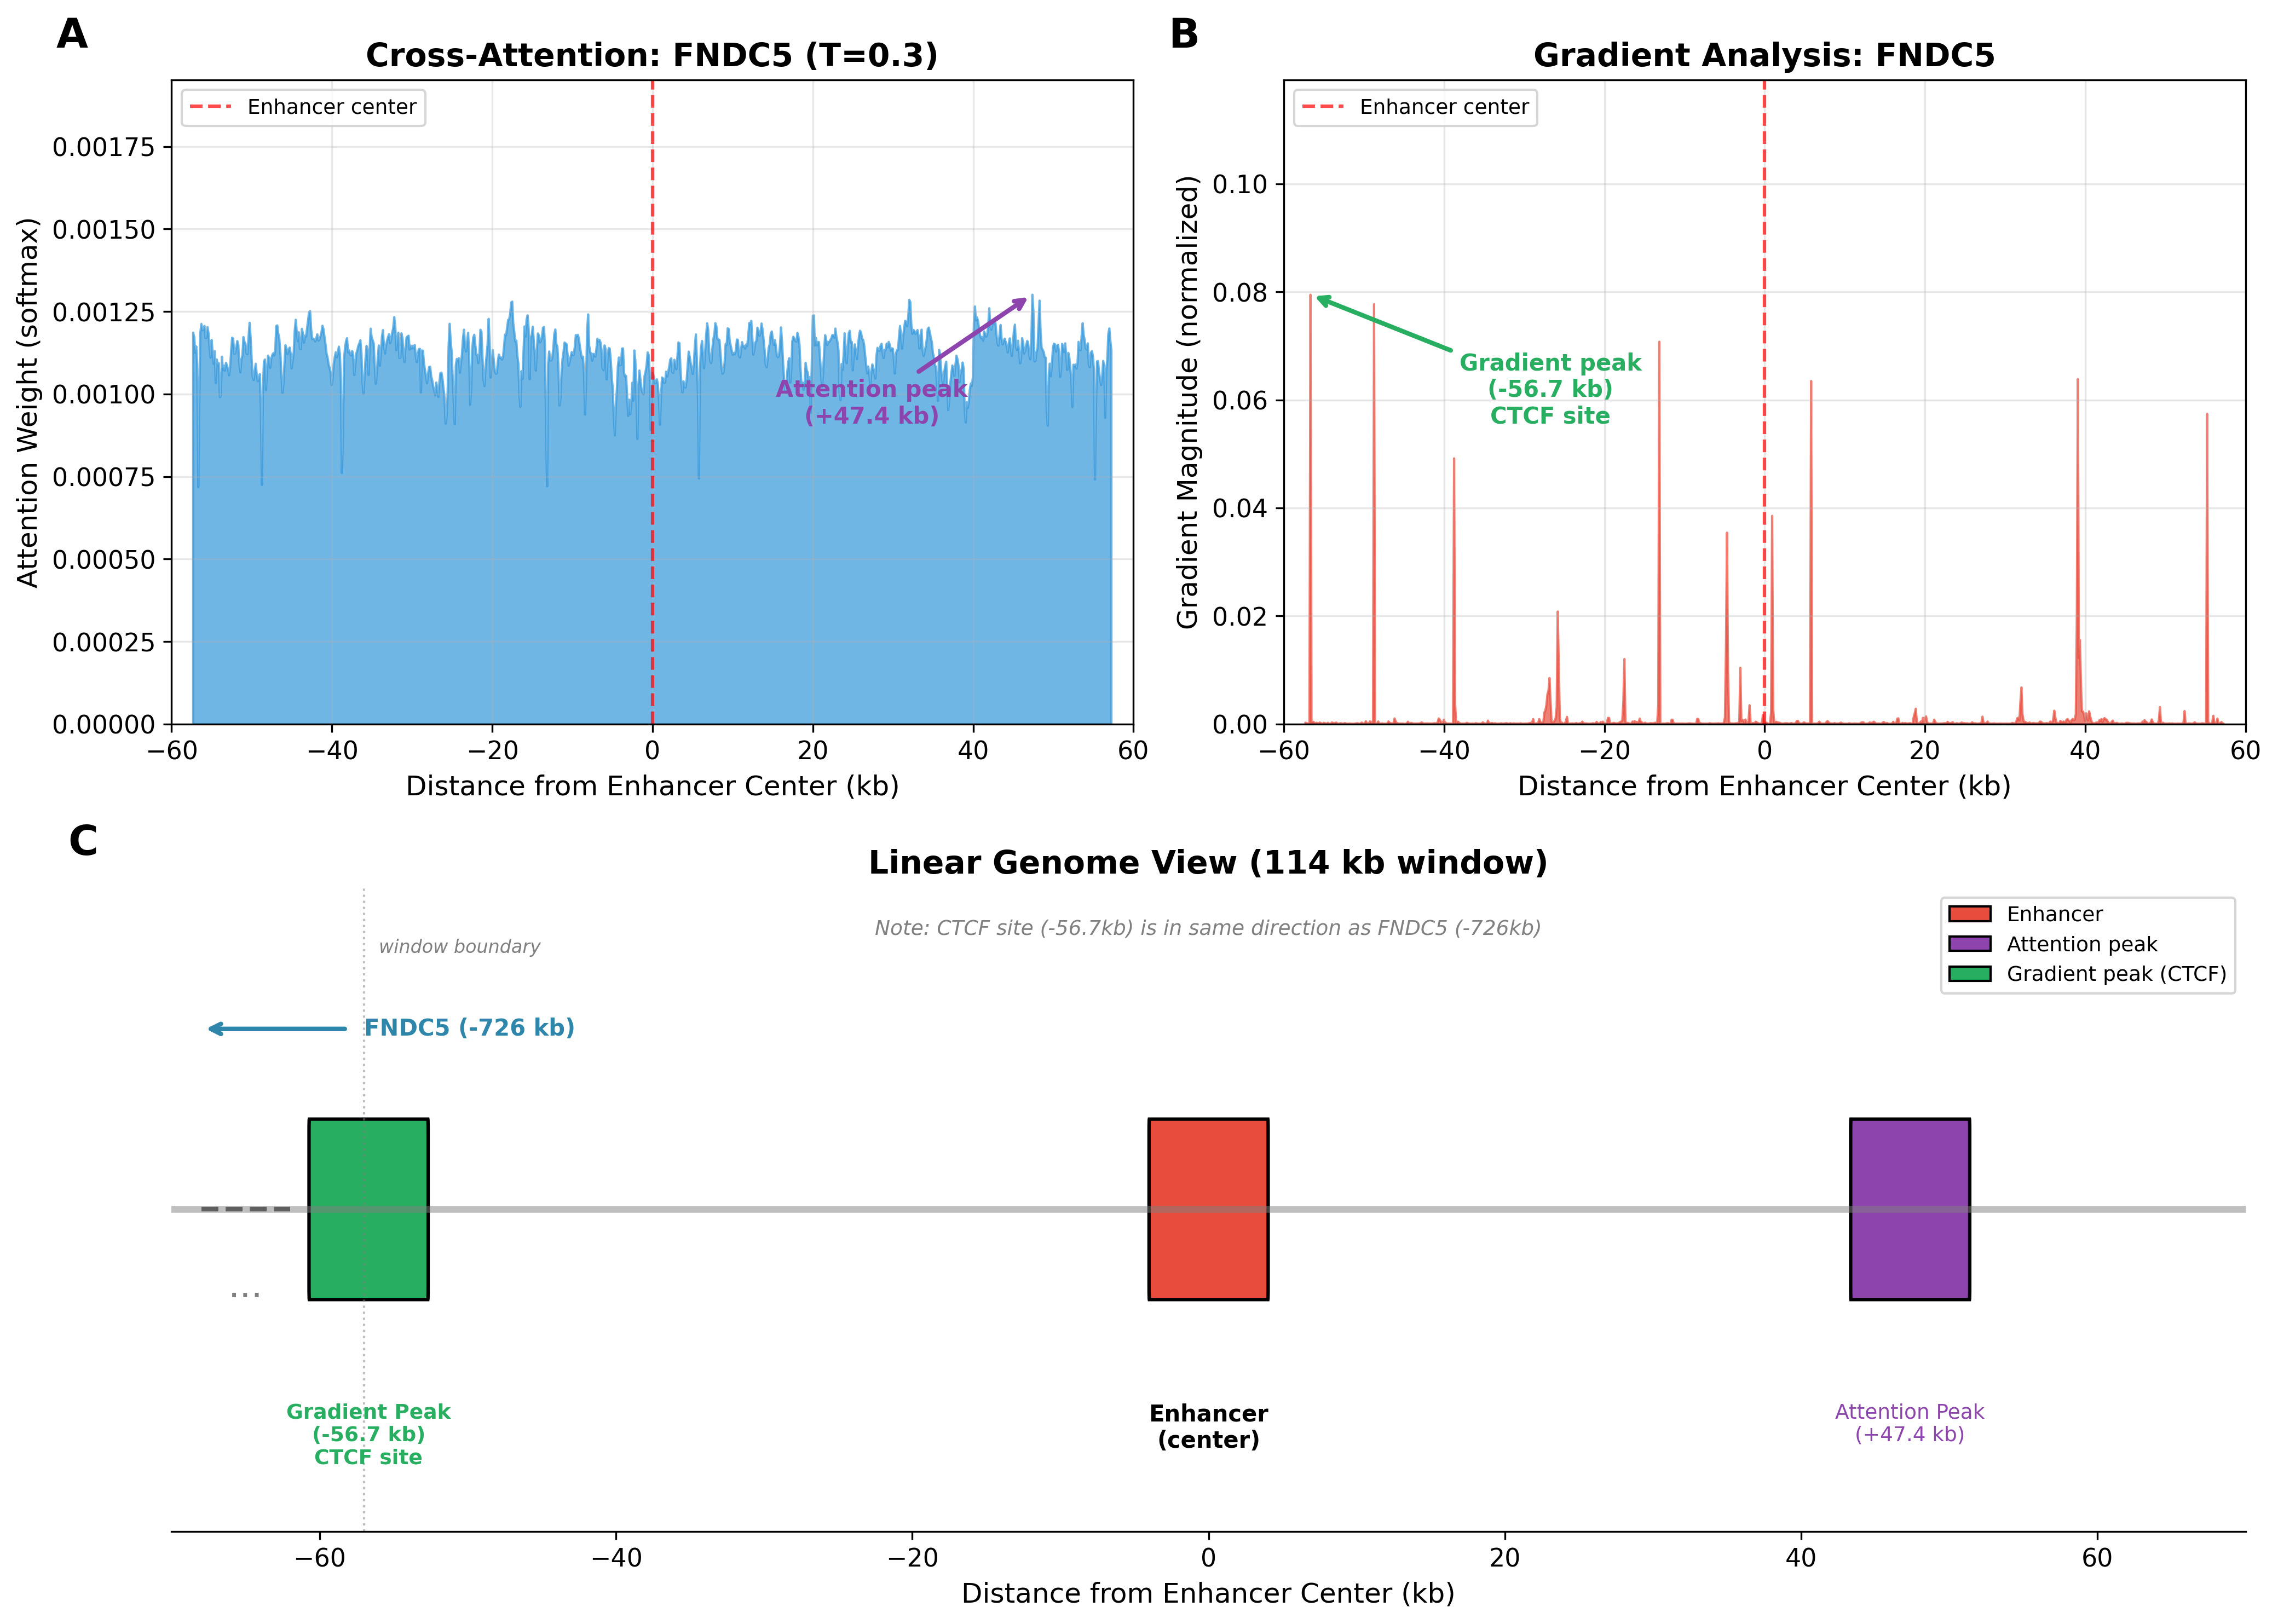


Figure saved as 'figure5_fndc5_case_study.png'


In [ ]:
# Create Figure 5 with temperature scaling and arrow annotations
positions_kb = np.array([bin_to_kb(i) for i in range(SEQ_LEN)])

# Temperature scaling for attention (to make peaks more visible)
temperature = 0.3  # Lower = sharper peaks
attention_log = np.log(gene_attention + 1e-10)
attention_scaled = np.exp(attention_log / temperature)
attention_scaled = attention_scaled / attention_scaled.sum()  # Re-normalize (softmax)

# Find peak after temperature scaling
attention_peak_bin_scaled = np.argmax(attention_scaled)
attention_peak_kb_scaled = bin_to_kb(attention_peak_bin_scaled)

print(f"After temperature scaling (T={temperature}):")
print(f"  Attention peak: bin {attention_peak_bin_scaled} ({attention_peak_kb_scaled:+.1f} kb)")
print(f"  Max attention value: {attention_scaled.max():.6f}")
print(f"  Sum of attention: {attention_scaled.sum():.6f}")

# Use softmax values directly (no max normalization)
use_max_normalization = False  # Set to True if peak is not visible

if use_max_normalization:
    attention_plot = attention_scaled / attention_scaled.max()
    gradient_plot = gradient_importance / gradient_importance.max()
    ylabel_attn = 'Normalized Attention'
    ylabel_grad = 'Normalized Gradient Magnitude'
else:
    attention_plot = attention_scaled  # Softmax values directly
    gradient_plot = gradient_importance / gradient_importance.sum()
    ylabel_attn = 'Attention Weight (softmax)'
    ylabel_grad = 'Gradient Magnitude (normalized)'

# Create figure
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

fig = plt.figure(figsize=(14, 10), dpi=300)

# Panel A: Attention map (with temperature scaling)
ax1 = fig.add_subplot(2, 2, 1)
ax1.fill_between(positions_kb, 0, attention_plot, alpha=0.7, color='#3498db')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Enhancer center')

# Arrow for attention peak
ax1.annotate(f'Attention peak\n({attention_peak_kb_scaled:+.1f} kb)',
             xy=(attention_peak_kb_scaled, attention_plot[attention_peak_bin_scaled]),
             xytext=(attention_peak_kb_scaled - 20, attention_plot.max() * 0.7),
             fontsize=10, fontweight='bold', color='#8e44ad',
             arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=2),
             ha='center')

ax1.set_xlabel('Distance from Enhancer Center (kb)', fontsize=12)
ax1.set_ylabel(ylabel_attn, fontsize=12)
ax1.set_title(f'Cross-Attention: {target_gene} (T={temperature})', fontsize=14, fontweight='bold')
ax1.set_xlim(-60, 60)
ax1.set_ylim(0, attention_plot.max() * 1.5)  # Increased Y-axis for annotation space
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.text(-0.12, 1.05, 'A', transform=ax1.transAxes, fontsize=18, fontweight='bold')

# Panel B: Gradient map
ax2 = fig.add_subplot(2, 2, 2)
ax2.fill_between(positions_kb, 0, gradient_plot, alpha=0.7, color='#e74c3c')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Enhancer center')

# Arrow for gradient peak
ax2.annotate(f'Gradient peak\n({gradient_peak_kb:+.1f} kb)\nCTCF site',
             xy=(gradient_peak_kb, gradient_plot[gradient_peak_bin]),
             xytext=(gradient_peak_kb + 30, gradient_plot.max() * 0.7),
             fontsize=10, fontweight='bold', color='#27ae60',
             arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2),
             ha='center')

ax2.set_xlabel('Distance from Enhancer Center (kb)', fontsize=12)
ax2.set_ylabel(ylabel_grad, fontsize=12)
ax2.set_title(f'Gradient Analysis: {target_gene}', fontsize=14, fontweight='bold')
ax2.set_xlim(-60, 60)
ax2.set_ylim(0, gradient_plot.max() * 1.5)  # Increased Y-axis for legend space
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.text(-0.12, 1.05, 'B', transform=ax2.transAxes, fontsize=18, fontweight='bold')

# Panel C: Linear genome view (improved FNDC5 display)
ax3 = fig.add_subplot(2, 1, 2)
ax3.axhline(y=0.5, color='gray', linewidth=3, alpha=0.5)

# FNDC5 is 726kb in the NEGATIVE direction - show as off-axis indicator
# Dashed line to indicate continuation outside window
ax3.plot([-68, -62], [0.5, 0.5], 'k--', linewidth=2, alpha=0.5)
ax3.text(-65, 0.38, '...', fontsize=16, ha='center', va='center', color='gray')

# FNDC5 label with horizontal arrow pointing left <-
ax3.annotate('',
             xy=(-68, 0.78),
             xytext=(-58, 0.78),
             arrowprops=dict(arrowstyle='->', color='#2E86AB', lw=2))
ax3.text(-57, 0.78, f'{target_gene} (-726 kb)',
         fontsize=10, color='#2E86AB', fontweight='bold',
         ha='left', va='center')

# Window boundary indicator
ax3.axvline(x=-57, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax3.text(-56, 0.92, 'window boundary', fontsize=8, ha='left', va='top',
         color='gray', style='italic')

# Gradient peak (CTCF site)
ax3.add_patch(FancyBboxPatch((gradient_peak_kb-4, 0.38), 8, 0.24, boxstyle="round,pad=0.02",
                              facecolor='#27ae60', edgecolor='black', linewidth=1.5))
ax3.text(gradient_peak_kb, 0.20, f'Gradient Peak\n({gradient_peak_kb:+.1f} kb)\nCTCF site',
         ha='center', va='top', fontsize=9, color='#27ae60', fontweight='bold')

# Enhancer (center)
ax3.add_patch(FancyBboxPatch((-4, 0.38), 8, 0.24, boxstyle="round,pad=0.02",
                              facecolor='#e74c3c', edgecolor='black', linewidth=1.5))
ax3.text(0, 0.20, 'Enhancer\n(center)', ha='center', va='top', fontsize=10, fontweight='bold')

# Attention peak
ax3.add_patch(FancyBboxPatch((attention_peak_kb_scaled-4, 0.38), 8, 0.24, boxstyle="round,pad=0.02",
                              facecolor='#8e44ad', edgecolor='black', linewidth=1.5))
ax3.text(attention_peak_kb_scaled, 0.20, f'Attention Peak\n({attention_peak_kb_scaled:+.1f} kb)',
         ha='center', va='top', fontsize=9, color='#8e44ad')

ax3.set_xlim(-70, 70)
ax3.set_ylim(0, 1.0)
ax3.set_xlabel('Distance from Enhancer Center (kb)', fontsize=12)
ax3.set_title('Linear Genome View (114 kb window)', fontsize=14, fontweight='bold')
ax3.set_yticks([])
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.text(-0.05, 1.05, 'C', transform=ax3.transAxes, fontsize=18, fontweight='bold')

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#e74c3c', edgecolor='black', label='Enhancer'),
    mpatches.Patch(facecolor='#8e44ad', edgecolor='black', label='Attention peak'),
    mpatches.Patch(facecolor='#27ae60', edgecolor='black', label='Gradient peak (CTCF)'),
]
ax3.legend(handles=legend_elements, loc='upper right', fontsize=9)

# Annotation
ax3.text(0, 0.92, f'Note: CTCF site ({gradient_peak_kb:+.1f}kb) is in same direction as {target_gene} (-726kb)',
         ha='center', va='bottom', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig('figure5_fndc5_case_study.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigure saved as 'figure5_fndc5_case_study.png'")

In [ ]:
# Summary
print("="*60)
print("Figure 5: FNDC5 Case Study - Summary")
print("="*60)
print(f"\nTemperature scaling: T = {temperature}")
print(f"\nSpatial relationship:")
print(f"  {target_gene}: -726 kb (far left, outside window)")
print(f"  Gradient peak (CTCF): {gradient_peak_kb:+.1f} kb (same direction as {target_gene})")
print(f"  Enhancer: 0 kb (center)")
print(f"  Attention peak: {attention_peak_kb_scaled:+.1f} kb")
print(f"\nKey finding:")
print(f"  CTCF site is between enhancer and target gene - consistent with chromatin looping model")

Figure 5: FNDC5 Case Study - Summary

Temperature scaling: T = 0.3

Spatial relationship:
  FNDC5: -726 kb (far left, outside window)
  Gradient peak (CTCF): -56.7 kb (same direction as FNDC5)
  Enhancer: 0 kb (center)
  Attention peak: +47.4 kb

Key finding:
  CTCF site is between enhancer and target gene - consistent with chromatin looping model


In [ ]:
# Download
from google.colab import files
files.download('figure5_fndc5_case_study.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
val_dataset.close()
print("Done!")